In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [4]:
# Check missing values
df.isnull().sum()

# Remove duplicates
df = df.drop_duplicates()

# Check data types
df.dtypes

# Save cleaned dataset
df.to_csv(
    "../data/processed/dataset4_cleaned.csv",
    index=False
)

In [6]:
df.shape

(48, 6)

In [7]:
df.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [9]:
df.describe()

,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
count,48.000000,48.000000,48.000000,48.000000,36.000000
mean,19577.520833,7.189583,9.893750,8.632083,31.456944
std,6354.329621,1.271457,5.370745,3.613579,11.768190
min,11438.000000,4.910000,7.500000,4.800000,15.800000
25%,13658.500000,6.110000,8.775000,5.790000,20.245000
50%,18224.000000,7.150000,9.200000,7.265000,28.295000
75%,25944.250000,8.300000,9.562500,10.525000,40.807500
max,31002.000000,9.350000,46.000000,15.900000,53.050000


In [10]:
df["month"] = pd.to_datetime(df["month"])

df.dtypes

month                        datetime64[us]
sip_inflow_crore                      int64
active_sip_accounts_crore           float64
new_sip_accounts_lakh               float64
sip_aum_lakh_crore                  float64
yoy_growth_pct                      float64
dtype: object

In [11]:
df.isnull().sum()

month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["month"].min(), df["month"].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2025-12-01 00:00:00'))

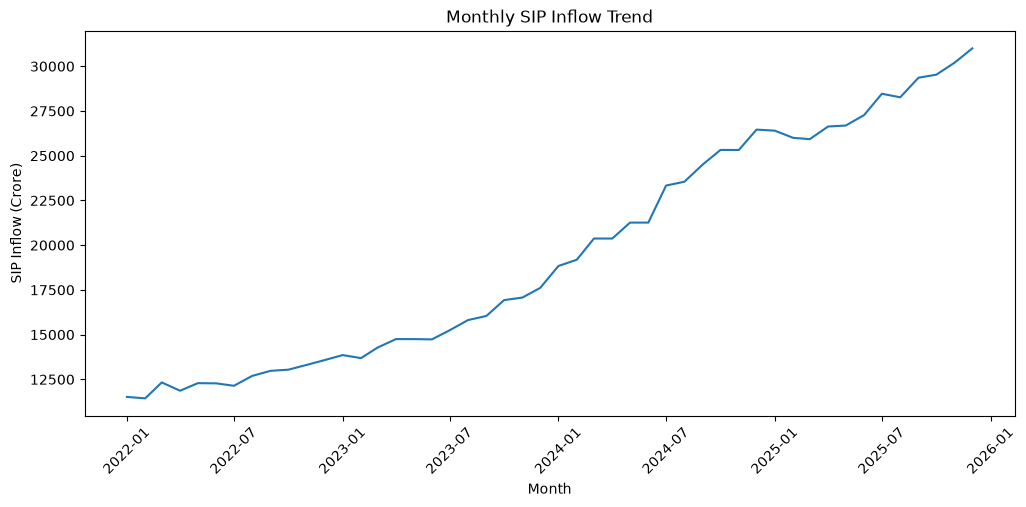

In [15]:
plt.figure(figsize=(12,5))

plt.plot(
    df["month"],
    df["sip_inflow_crore"]
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.xticks(rotation=45)

plt.show()

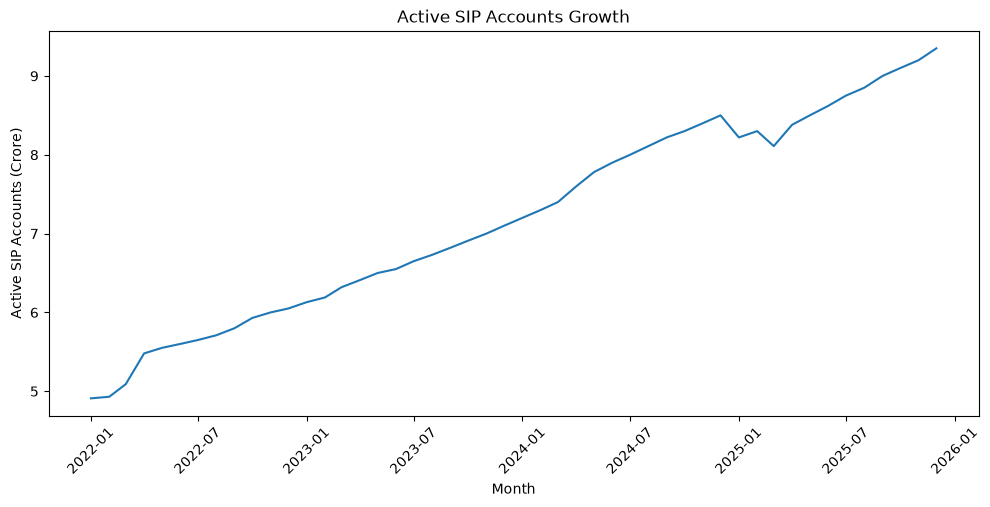

In [16]:
plt.figure(figsize=(12,5))

plt.plot(
    df["month"],
    df["active_sip_accounts_crore"]
)

plt.title("Active SIP Accounts Growth")
plt.xlabel("Month")
plt.ylabel("Active SIP Accounts (Crore)")

plt.xticks(rotation=45)

plt.show()

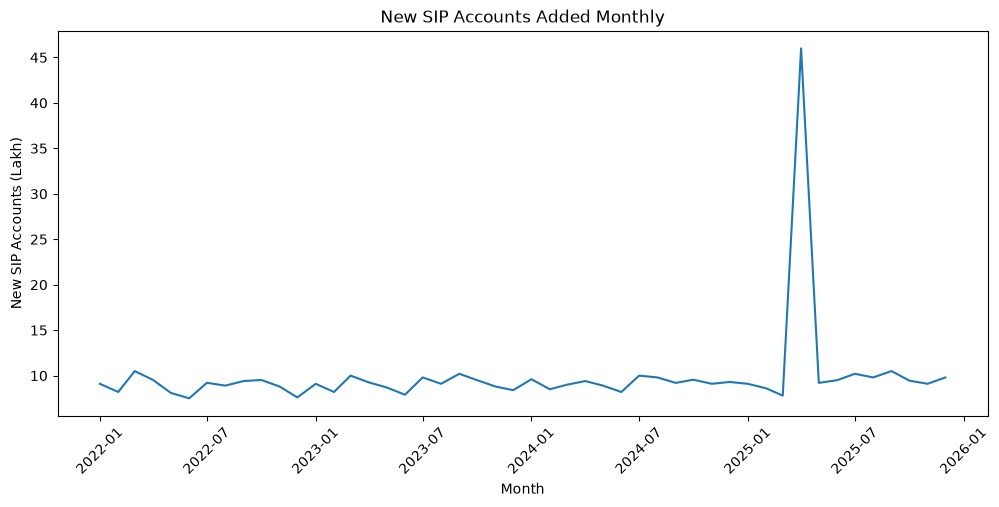

In [17]:
plt.figure(figsize=(12,5))

plt.plot(
    df["month"],
    df["new_sip_accounts_lakh"]
)

plt.title("New SIP Accounts Added Monthly")
plt.xlabel("Month")
plt.ylabel("New SIP Accounts (Lakh)")

plt.xticks(rotation=45)

plt.show()

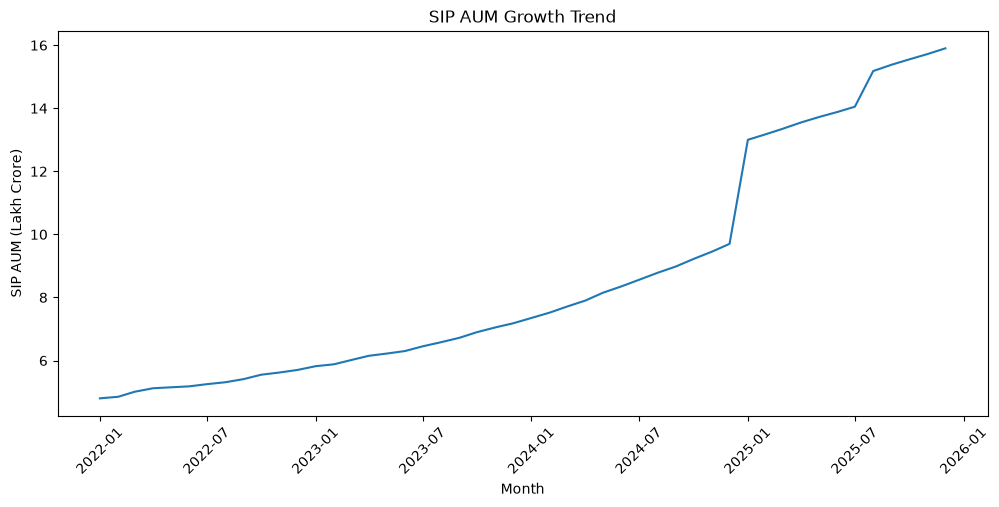

In [18]:
plt.figure(figsize=(12,5))

plt.plot(
    df["month"],
    df["sip_aum_lakh_crore"]
)

plt.title("SIP AUM Growth Trend")
plt.xlabel("Month")
plt.ylabel("SIP AUM (Lakh Crore)")

plt.xticks(rotation=45)

plt.show()

In [19]:
growth_df = df.dropna(subset=["yoy_growth_pct"])

growth_df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
12,2023-01-01,13856,6.13,9.10,5.82,20.31
13,2023-02-01,13687,6.19,8.20,5.88,19.66
14,2023-03-01,14276,6.32,10.00,6.01,15.80
15,2023-04-01,14749,6.41,9.25,6.15,24.33
16,2023-05-01,14749,6.50,8.70,6.22,20.05


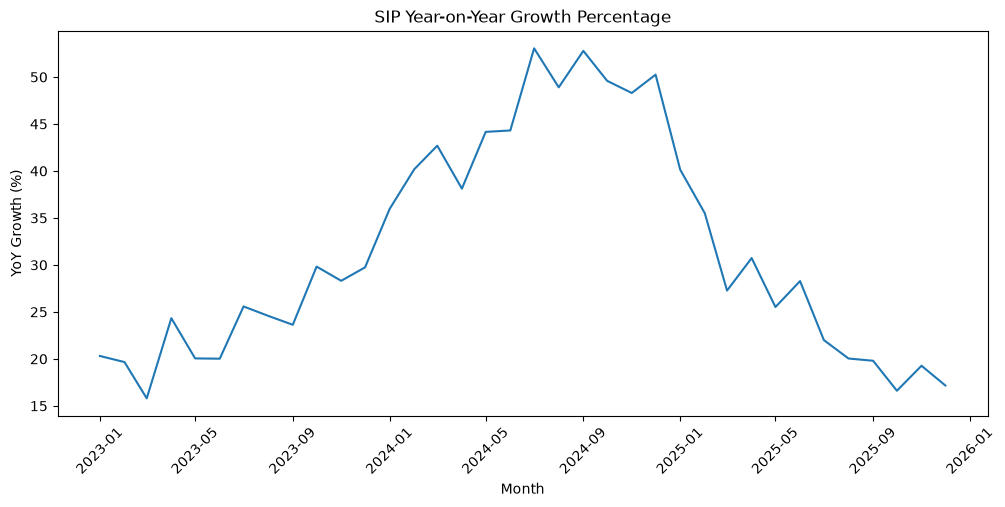

In [20]:
plt.figure(figsize=(12,5))

plt.plot(
    growth_df["month"],
    growth_df["yoy_growth_pct"]
)

plt.title("SIP Year-on-Year Growth Percentage")
plt.xlabel("Month")
plt.ylabel("YoY Growth (%)")

plt.xticks(rotation=45)

plt.show()

In [21]:
df.loc[
    df["sip_inflow_crore"].idxmax()
]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [23]:
df.loc[
    df["sip_aum_lakh_crore"].idxmax()
]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [22]:
df.corr(numeric_only=True)

,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
sip_inflow_crore,1.000000,0.980030,0.201859,0.947644,0.149050
active_sip_accounts_crore,0.980030,1.000000,0.174692,0.904550,0.177684
new_sip_accounts_lakh,0.201859,0.174692,1.000000,0.234437,-0.017008
sip_aum_lakh_crore,0.947644,0.904550,0.234437,1.000000,-0.187184
yoy_growth_pct,0.149050,0.177684,-0.017008,-0.187184,1.000000


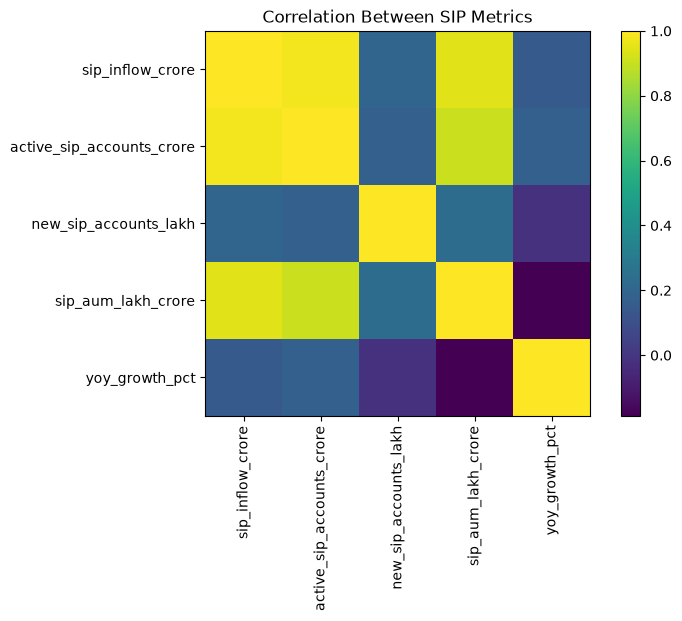

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.imshow(
    df.corr(numeric_only=True)
)

plt.colorbar()

plt.xticks(
    range(len(df.corr(numeric_only=True).columns)),
    df.corr(numeric_only=True).columns,
    rotation=90
)

plt.yticks(
    range(len(df.corr(numeric_only=True).columns)),
    df.corr(numeric_only=True).columns
)

plt.title("Correlation Between SIP Metrics")

plt.show()

# Insights from SIP Analysis Dataset

## Dataset Overview
- Dataset contains monthly SIP investment statistics.
- Analysis period covers January 2022 to December 2025.
- Key metrics include SIP inflow, active SIP accounts, new SIP accounts, SIP AUM and YoY growth.

## Data Quality
- Month column was converted into datetime format.
- Missing YoY growth values were observed for initial months due to unavailable previous year comparison.
- No duplicate records were identified.

## SIP Growth Analysis
- Monthly SIP inflows show a consistent increasing trend.
- Active SIP accounts increased over time, indicating higher investor participation.
- SIP AUM showed strong growth throughout the analysis period.

## Key Observation
The growth in SIP inflows and investor accounts indicates increasing adoption of systematic investment plans among mutual fund investors.